# Selección de Activos para Valuación de Opciones Americanas
## Tesis: LSM-SVR — UNAM Ciencias Actuariales

Este notebook evalúa cuantitativamente candidatos del **Top 20 BMV** y del
**mercado americano** para seleccionar:
- **2 emisoras mexicanas** (BMV)
- **2 emisoras internacionales** (referencia estándar en la literatura)

### Criterios de selección
| Criterio | Descripción |
|---|---|
| Historial | Años de datos disponibles en yfinance |
| Completitud | % de datos faltantes (NaN en precios) |
| Volumen | Volumen promedio diario (liquidez) |
| Volatilidad anualizada | σ de rendimientos log-diarios × √252 |
| Bursatilidad | Días con volumen > 0 / total días |
| Normalidad | p-valor Jarque-Bera (rendimientos) |
| Curtosis | Exceso de curtosis de rendimientos |


## 1. Dependencias

In [1]:
import subprocess, sys
for p in ["yfinance", "pandas", "numpy", "matplotlib", "scipy", "seaborn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])
print("✅ Dependencias listas")



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


✅ Dependencias listas



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


## 2. Importaciones

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
from datetime import datetime, date

# ── Ruta de datos ─────────────────────────────────────────────────────────────

# (eliminado: ya no se guarda nada en disco)

# ── Parámetros de descarga ────────────────────────────────────────────────────
FECHA_INICIO   = '2010-01-01'   # mínimo 14 años de historial
FECHA_FIN      = date.today().strftime('%Y-%m-%d')
MIN_ANOS       = 8              # filtro mínimo: 8 años
MIN_BURSATILIDAD = 0.85         # 85% días con volumen
print(f"Periodo de análisis: {FECHA_INICIO} → {FECHA_FIN}")
print("✅ Importaciones y configuración listas")


Periodo de análisis: 2010-01-01 → 2026-09-05
✅ Importaciones y configuración listas


## 3. Candidatos

### BMV — Top 20 por capitalización / bursatilidad
Incluye las emisoras más líquidas del IPC y sus series principales.

### Mercado americano — Referencias estándar en literatura de opciones
S&P 500, tecnología y finanzas — los más citados en papers de LSM.


In [3]:
# ── Candidatos BMV ────────────────────────────────────────────────────────────
# Sufijo .MX para yfinance (Bolsa Mexicana de Valores)
CANDIDATOS_MX = {
    'AMXL.MX':      'América Móvil L',
    'GMEXICOB.MX':  'Grupo México B',
    'FEMSAUBD.MX':  'FEMSA UBD',
    'WALMEX.MX':    'Walmart de México',
    'GCARSOA1.MX':  'Grupo Carso A1',
    'AC.MX':        'Arca Continental',
    'BIMBOA.MX':    'Grupo Bimbo A',
    'GFINBURO.MX':  'Grupo Financiero Inbursa',
    'GFNORTEO.MX':  'Banorte O',
    'CEMEXCPO.MX':  'CEMEX CPO',
    'TLEVISACPO.MX':'Televisa CPO',
    'ALFAA.MX':     'Alfa A',
    'LABB.MX':      'Genomma Lab B',
    'PINFRA.MX':    'PINFRA',
    'IENOVA.MX':    'IEnova',
    'KIMBERA.MX':   'Kimberly-Clark México A',
    'LIVEPOLC1.MX': 'Liverpool C1',
    'ORBIA.MX':     'Orbia',
    'MEGACPO.MX':   'Megacable CPO',
    'GRUMAB.MX':    'Gruma B',
}

# ── Candidatos internacionales ────────────────────────────────────────────────
CANDIDATOS_US = {
    'AAPL':  'Apple Inc.',
    'MSFT':  'Microsoft Corp.',
    'SPY':   'SPDR S&P 500 ETF',
    'QQQ':   'Invesco QQQ (Nasdaq)',
    'AMZN':  'Amazon.com Inc.',
    'GOOGL': 'Alphabet Inc. A',
    'META':  'Meta Platforms',
    'TSLA':  'Tesla Inc.',
    'JPM':   'JPMorgan Chase',
    'GS':    'Goldman Sachs',
    'BAC':   'Bank of America',
    'XOM':   'ExxonMobil',
    'JNJ':   'Johnson & Johnson',
    'KO':    'Coca-Cola Co.',
    'PG':    'Procter & Gamble',
    'WMT':   'Walmart Inc.',
    'V':     'Visa Inc.',
    'BRK-B': 'Berkshire Hathaway B',
    'NFLX':  'Netflix Inc.',
    'NVDA':  'NVIDIA Corp.',
}

print(f"Candidatos BMV:           {len(CANDIDATOS_MX)}")
print(f"Candidatos internacionales: {len(CANDIDATOS_US)}")


Candidatos BMV:           20
Candidatos internacionales: 20


## 4. Descarga y Evaluación Cuantitativa

In [4]:
def evaluar_activo(ticker: str, nombre: str,
                   inicio: str = FECHA_INICIO,
                   fin: str    = FECHA_FIN) -> dict:
    """
    Descarga datos de yfinance y calcula todos los criterios de selección.
    Retorna dict con métricas o None si no hay datos suficientes.
    """
    base = {
        'ticker': ticker, 'nombre': nombre,
        'disponible': False, 'anos': 0,
        'n_obs': 0, 'pct_nan': 100.0,
        'bursatilidad': 0.0, 'vol_promedio': 0,
        'sigma': np.nan, 'mu': np.nan,
        'curtosis': np.nan, 'asimetria': np.nan,
        'jb_pval': np.nan, 'precio_actual': np.nan,
        'fecha_inicio_real': None, 'fecha_fin_real': None,
    }
    try:
        df = yf.Ticker(ticker).history(start=inicio, end=fin, auto_adjust=True)
        if df.empty or len(df) < 252:          # mínimo 1 año de datos
            return base

        df.index = pd.to_datetime(df.index).tz_localize(None)
        close    = df['Close'].dropna()
        volume   = df['Volume'].fillna(0)

        if len(close) < 252:
            return base

        log_ret  = np.log(close / close.shift(1)).dropna()
        anos     = (close.index[-1] - close.index[0]).days / 365.25
        pct_nan  = df['Close'].isna().mean() * 100
        burs     = (volume > 0).mean()
        sigma    = float(log_ret.std() * np.sqrt(252))
        mu       = float(log_ret.mean() * 252)
        kurt     = float(log_ret.kurt())        # exceso de curtosis (scipy)
        skew     = float(log_ret.skew())
        jb_stat, jb_p = stats.jarque_bera(log_ret)
        vol_prom = int(volume.mean())
        p_act    = float(close.iloc[-1])

        return {
            'ticker':           ticker,
            'nombre':           nombre,
            'disponible':       True,
            'anos':             round(anos, 1),
            'n_obs':            len(close),
            'pct_nan':          round(pct_nan, 2),
            'bursatilidad':     round(burs, 4),
            'vol_promedio':     vol_prom,
            'sigma':            round(sigma, 4),
            'mu':               round(mu, 4),
            'curtosis':         round(kurt, 4),
            'asimetria':        round(skew, 4),
            'jb_pval':          round(jb_p, 6),
            'precio_actual':    round(p_act, 2),
            'fecha_inicio_real': str(close.index[0].date()),
            'fecha_fin_real':    str(close.index[-1].date()),
        }
    except Exception as e:
        base['error'] = str(e)
        return base


print("✅ Función evaluar_activo definida")


✅ Función evaluar_activo definida


In [5]:
# ── Evaluar todos los candidatos BMV ─────────────────────────────────────────
print("Evaluando candidatos BMV...")
resultados_mx = []
for ticker, nombre in CANDIDATOS_MX.items():
    print(f"  {ticker:<20} ", end='')
    r = evaluar_activo(ticker, nombre)
    resultados_mx.append(r)
    status = f"✅ {r['anos']}a  σ={r['sigma']:.3f}  burs={r['bursatilidad']:.2f}" if r['disponible'] else "❌ Sin datos"
    print(status)

df_mx = pd.DataFrame(resultados_mx)
print(f"\nDisponibles: {df_mx['disponible'].sum()} / {len(df_mx)}")


Evaluando candidatos BMV...
  AMXL.MX              

$AMXL.MX: possibly delisted; no timezone found


❌ Sin datos
  GMEXICOB.MX          ✅ 16.7a  σ=0.326  burs=1.00
  FEMSAUBD.MX          ✅ 16.7a  σ=0.226  burs=1.00
  WALMEX.MX            ✅ 16.7a  σ=0.247  burs=1.00
  GCARSOA1.MX          ✅ 16.7a  σ=0.347  burs=1.00
  AC.MX                ✅ 16.7a  σ=0.216  burs=1.00
  BIMBOA.MX            ✅ 16.7a  σ=0.289  burs=1.00
  GFINBURO.MX          ✅ 16.7a  σ=0.317  burs=1.00
  GFNORTEO.MX          ✅ 16.7a  σ=0.316  burs=1.00
  CEMEXCPO.MX          ✅ 16.7a  σ=0.372  burs=1.00
  TLEVISACPO.MX        ✅ 16.7a  σ=0.348  burs=0.99
  ALFAA.MX             

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ALFAA.MX"}}}
$ALFAA.MX: possibly delisted; no timezone found


❌ Sin datos
  LABB.MX              ✅ 16.7a  σ=0.359  burs=1.00
  PINFRA.MX            ✅ 16.7a  σ=0.248  burs=1.00
  IENOVA.MX            

$IENOVA.MX: possibly delisted; no timezone found


❌ Sin datos
  KIMBERA.MX           

$LIVEPOLC1.MX: possibly delisted; no price data found  (1d 2010-01-01 -> 2026-09-05)


✅ 16.7a  σ=0.262  burs=1.00
  LIVEPOLC1.MX         ❌ Sin datos
  ORBIA.MX             ✅ 16.7a  σ=0.310  burs=0.99
  MEGACPO.MX           ✅ 16.7a  σ=0.279  burs=0.99
  GRUMAB.MX            ✅ 16.7a  σ=0.273  burs=1.00

Disponibles: 16 / 20


In [6]:
# ── Evaluar todos los candidatos internacionales ──────────────────────────────
print("Evaluando candidatos internacionales...")
resultados_us = []
for ticker, nombre in CANDIDATOS_US.items():
    print(f"  {ticker:<8} ", end='')
    r = evaluar_activo(ticker, nombre)
    resultados_us.append(r)
    status = f"✅ {r['anos']}a  σ={r['sigma']:.3f}  burs={r['bursatilidad']:.2f}" if r['disponible'] else "❌ Sin datos"
    print(status)

df_us = pd.DataFrame(resultados_us)
print(f"\nDisponibles: {df_us['disponible'].sum()} / {len(df_us)}")


Evaluando candidatos internacionales...
  AAPL     ✅ 16.7a  σ=0.281  burs=1.00
  MSFT     ✅ 16.7a  σ=0.260  burs=1.00
  SPY      ✅ 16.7a  σ=0.171  burs=1.00
  QQQ      ✅ 16.7a  σ=0.207  burs=1.00
  AMZN     ✅ 16.7a  σ=0.329  burs=1.00
  GOOGL    ✅ 16.7a  σ=0.278  burs=1.00
  META     ✅ 14.3a  σ=0.399  burs=1.00
  TSLA     ✅ 16.2a  σ=0.572  burs=1.00
  JPM      ✅ 16.7a  σ=0.274  burs=1.00
  GS       ✅ 16.7a  σ=0.291  burs=1.00
  BAC      ✅ 16.7a  σ=0.329  burs=1.00
  XOM      ✅ 16.7a  σ=0.250  burs=1.00
  JNJ      ✅ 16.7a  σ=0.171  burs=1.00
  KO       ✅ 16.7a  σ=0.172  burs=1.00
  PG       ✅ 16.7a  σ=0.174  burs=1.00
  WMT      ✅ 16.7a  σ=0.200  burs=1.00
  V        ✅ 16.7a  σ=0.248  burs=1.00
  BRK-B    ✅ 16.7a  σ=0.192  burs=1.00
  NFLX     ✅ 16.7a  σ=0.489  burs=1.00
  NVDA     ✅ 16.7a  σ=0.452  burs=1.00

Disponibles: 20 / 20


## 5. Score Compuesto y Ranking

In [7]:
def calcular_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Score compuesto 0-100 ponderando los criterios de selección.
    
    Pesos:
      40% Historial (años)        — más historia = más robusto para simulación
      25% Bursatilidad            — liquidez operacional
      20% Completitud datos       — menos NaN = mejor
      15% Volumen promedio        — liquidez absoluta
    
    Volatilidad NO penaliza: σ alta es información, no defecto.
    Se filtra por mínimos antes de puntuar.
    """
    d = df[df['disponible']].copy()

    # Filtros mínimos
    d = d[d['anos']         >= MIN_ANOS]
    d = d[d['bursatilidad'] >= MIN_BURSATILIDAD]
    d = d[d['pct_nan']      <= 5.0]

    if d.empty:
        return d

    def norm01(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else pd.Series(0.5, index=s.index)

    d['s_anos']    = norm01(d['anos'])          * 40
    d['s_burs']    = norm01(d['bursatilidad'])  * 25
    d['s_compl']   = norm01(100 - d['pct_nan']) * 20
    d['s_vol']     = norm01(np.log1p(d['vol_promedio'])) * 15

    d['score'] = (d['s_anos'] + d['s_burs'] + d['s_compl'] + d['s_vol']).round(2)
    return d.sort_values('score', ascending=False).reset_index(drop=True)


df_mx_rank = calcular_score(df_mx)
df_us_rank = calcular_score(df_us)

print("=== TOP BMV ===")
cols_show = ['ticker','nombre','anos','bursatilidad','pct_nan','sigma','vol_promedio','score']
print(df_mx_rank[cols_show].to_string(index=False))

print("\n=== TOP INTERNACIONALES ===")
print(df_us_rank[cols_show].to_string(index=False))


=== TOP BMV ===
       ticker                   nombre  anos  bursatilidad  pct_nan  sigma  vol_promedio  score
    WALMEX.MX        Walmart de México  16.7        0.9969     0.00 0.2469      17103459  70.25
        AC.MX         Arca Continental  16.7        0.9978     0.00 0.2156       1394385  68.51
  GFNORTEO.MX                Banorte O  16.7        0.9967     0.00 0.3157       6536216  65.45
  GMEXICOB.MX           Grupo México B  16.7        0.9962     0.00 0.3260       8785033  62.67
  GFINBURO.MX Grupo Financiero Inbursa  16.7        0.9967     0.00 0.3169       2708475  62.44
    PINFRA.MX                   PINFRA  16.7        0.9974     0.00 0.2485        499193  61.97
    BIMBOA.MX            Grupo Bimbo A  16.7        0.9967     0.00 0.2892       2355012  61.96
   KIMBERA.MX  Kimberly-Clark México A  16.7        0.9964     0.00 0.2624       3880549  61.40
  CEMEXCPO.MX                CEMEX CPO  16.7        0.9952     0.00 0.3724      40343378  60.30
    GRUMAB.MX           

## 6. Guardar Rankings

In [8]:
## 6. Guardar Rankings
print("✅ Rankings calculados en memoria (df_mx_rank, df_us_rank) — no se guardan a disco")

✅ Rankings calculados en memoria (df_mx_rank, df_us_rank) — no se guardan a disco


## 7. Visualización de Criterios

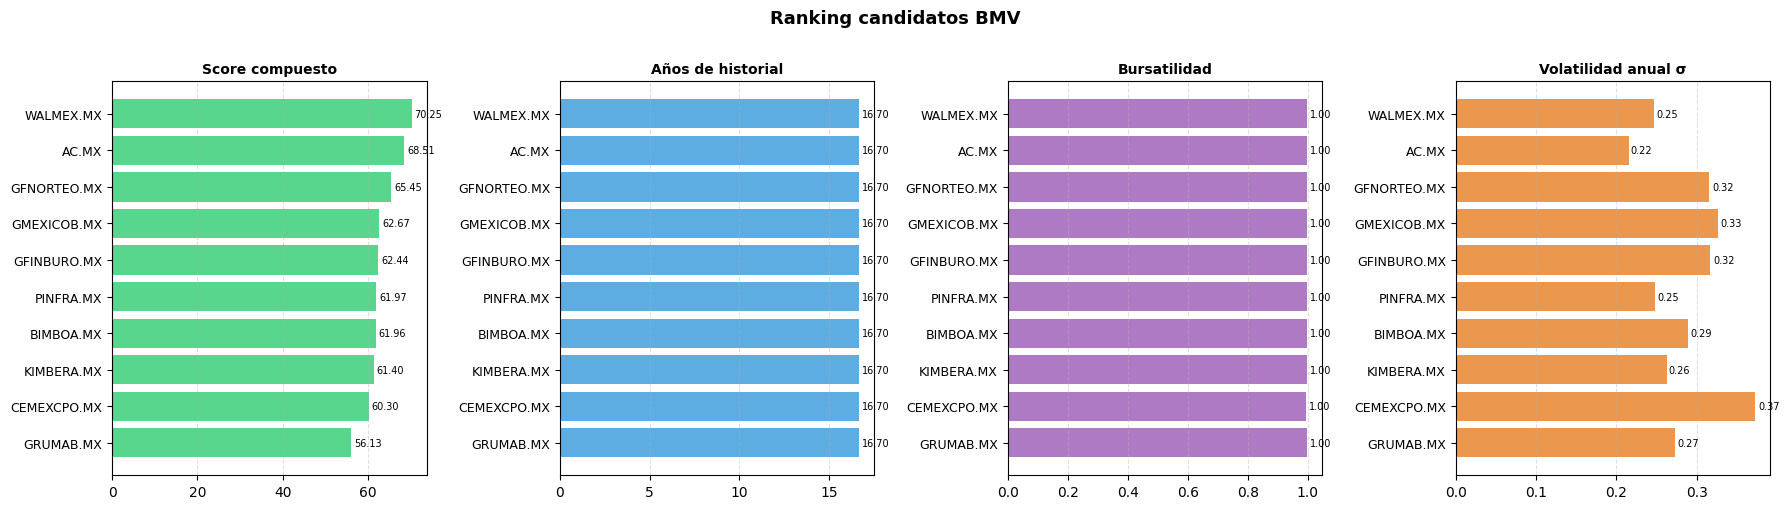

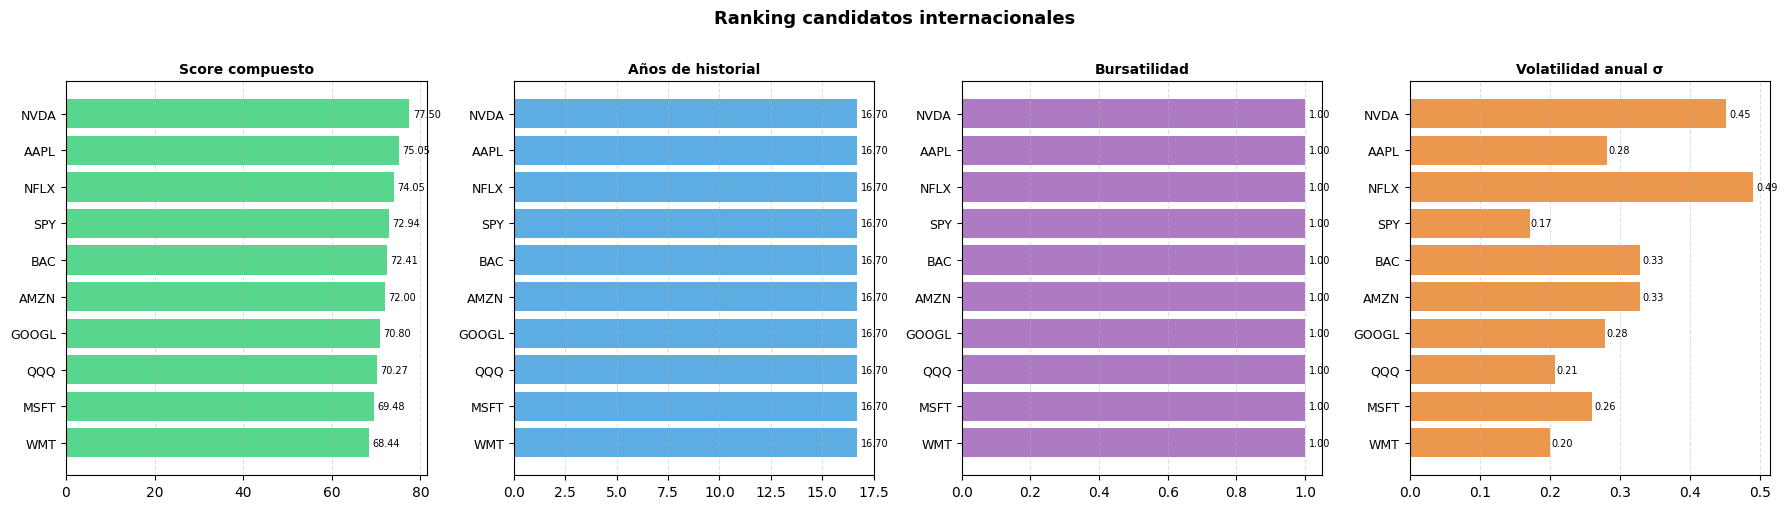

In [9]:
def graficar_ranking(df: pd.DataFrame, titulo: str, top_n: int = 10) -> None:
    """Gráfica de barras horizontales con score y métricas clave."""
    d = df.head(top_n).copy()
    fig, axes = plt.subplots(1, 4, figsize=(18, max(4, top_n * 0.5)))

    metricas = [
        ('score',        'Score compuesto', '#2ecc71'),
        ('anos',         'Años de historial', '#3498db'),
        ('bursatilidad', 'Bursatilidad', '#9b59b6'),
        ('sigma',        'Volatilidad anual σ', '#e67e22'),
    ]

    for ax, (col, label, color) in zip(axes, metricas):
        vals   = d[col].values
        labels = d['ticker'].values
        bars   = ax.barh(range(len(vals)), vals, color=color, alpha=0.8)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=9)
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.invert_yaxis()
        for bar, val in zip(bars, vals):
            ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}', va='center', fontsize=7)
        ax.grid(axis='x', linestyle='--', alpha=0.4)

    plt.suptitle(titulo, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


graficar_ranking(df_mx_rank, 'Ranking candidatos BMV')
graficar_ranking(df_us_rank, 'Ranking candidatos internacionales')


## 8. Análisis Detallado — Top 5 de Cada Grupo

=== Análisis detallado — Top 5 BMV ===


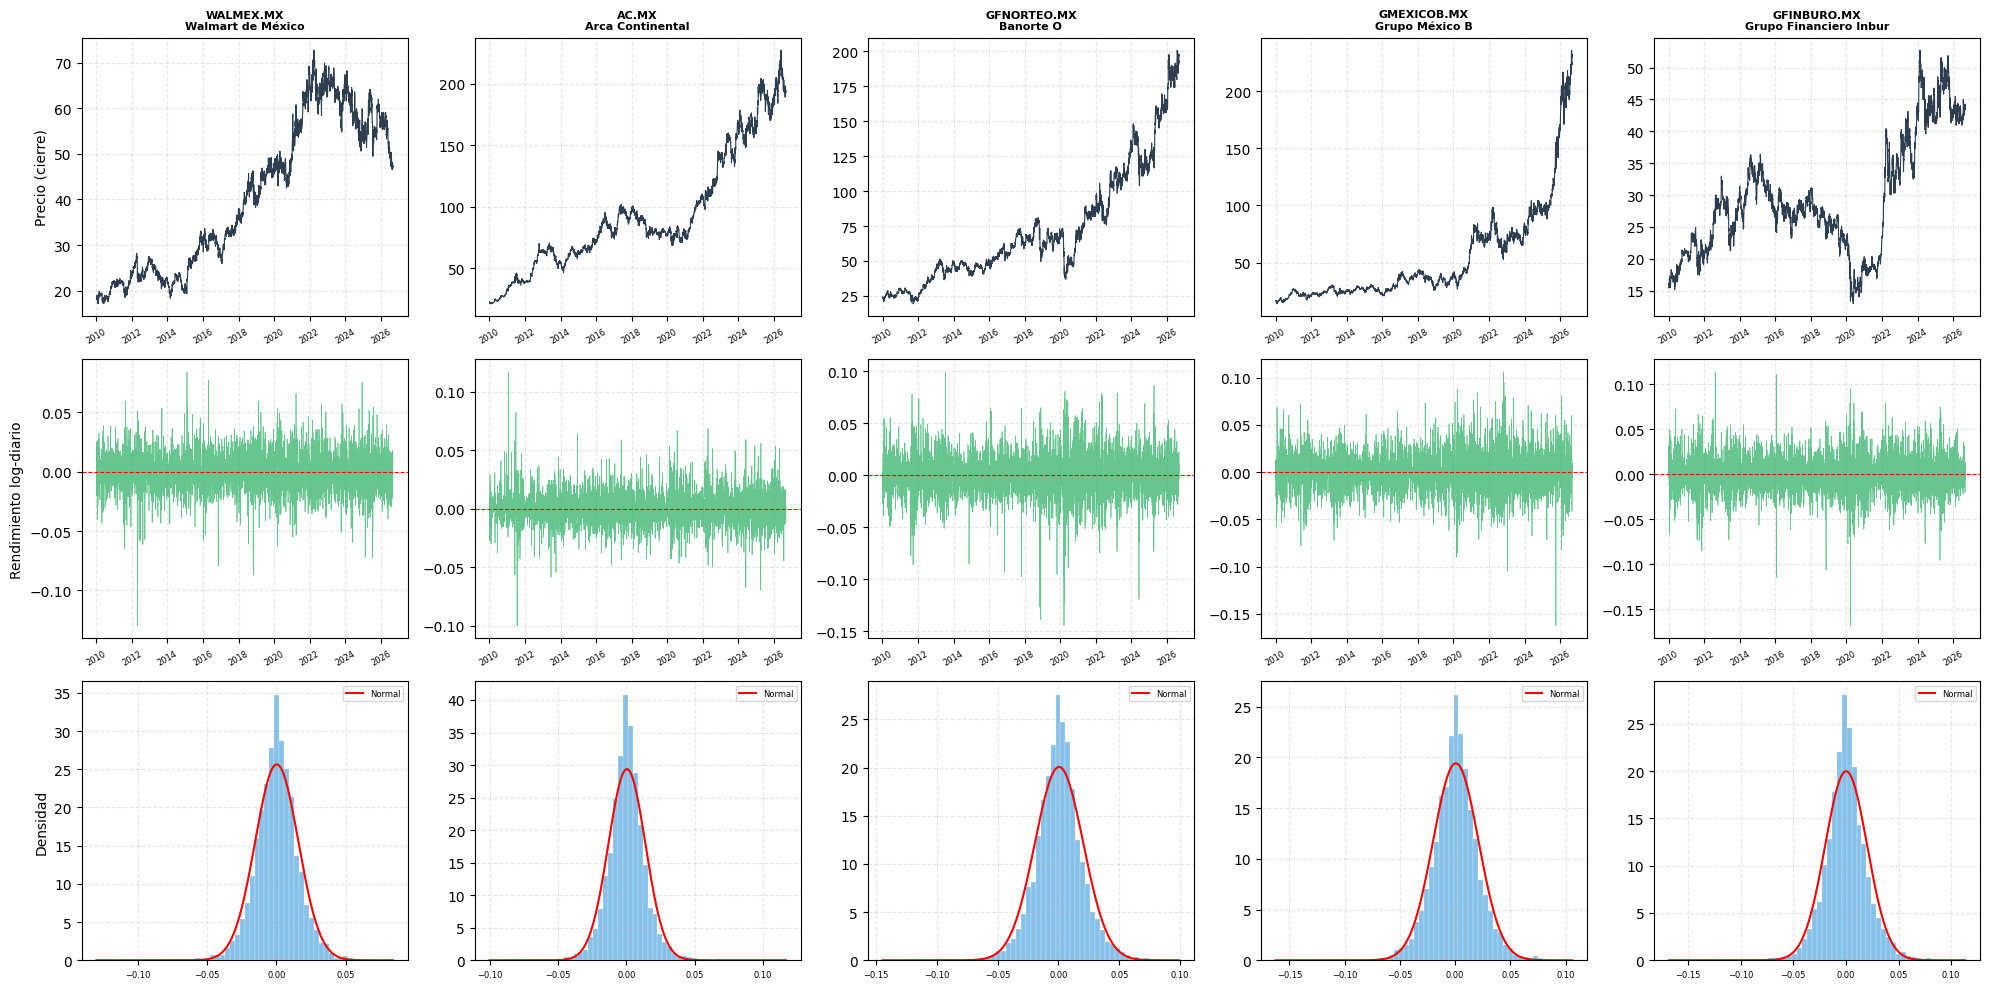


=== Análisis detallado — Top 5 Internacionales ===


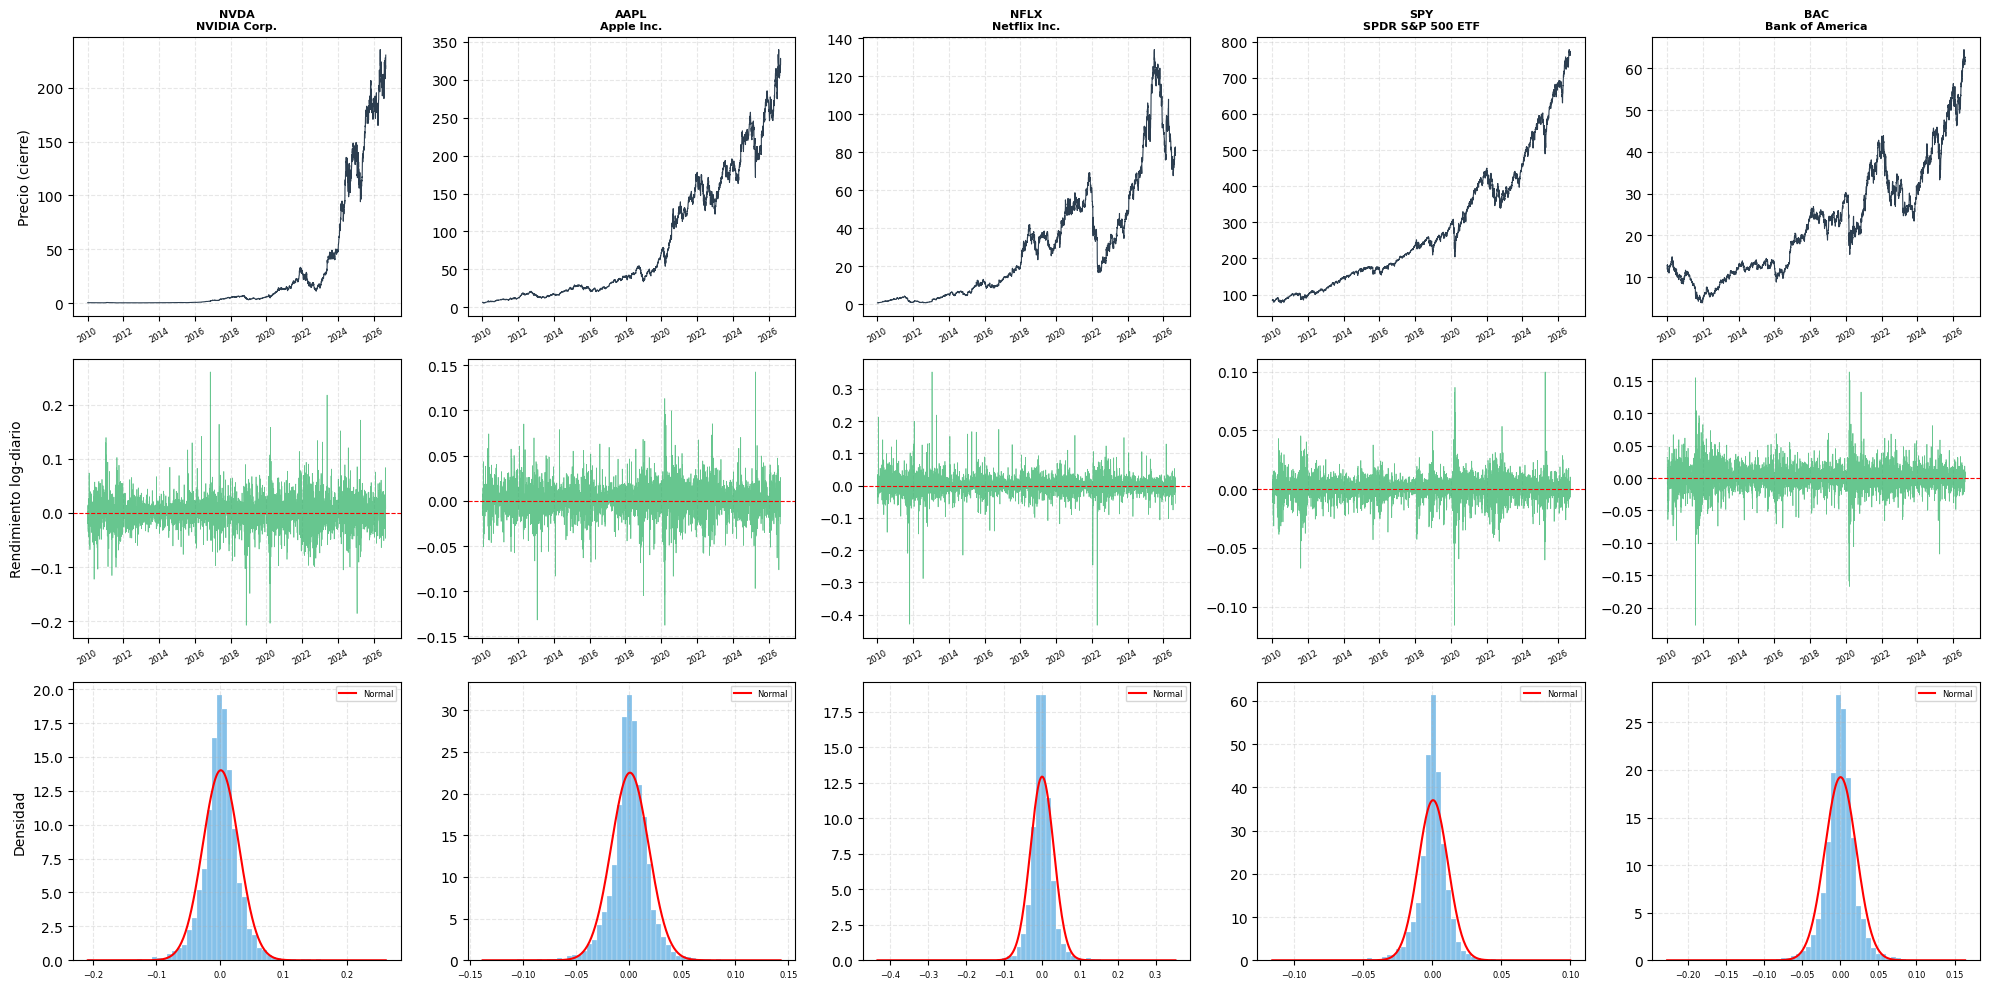

In [10]:
def analisis_detallado(df_rank: pd.DataFrame, n: int = 5,
                        inicio: str = FECHA_INICIO) -> None:
    """
    Para el top-n: precios históricos, rendimientos y estadísticos descriptivos.
    """
    top = df_rank.head(n)
    fig, axes = plt.subplots(3, n, figsize=(4*n, 10))

    for col_idx, (_, row) in enumerate(top.iterrows()):
        ticker = row['ticker']
        hist   = yf.Ticker(ticker).history(start=inicio, auto_adjust=True)
        hist.index = pd.to_datetime(hist.index).tz_localize(None)
        close  = hist['Close'].dropna()
        log_r  = np.log(close / close.shift(1)).dropna()

        # Fila 1: Precio histórico
        ax = axes[0, col_idx]
        ax.plot(close.index, close.values, linewidth=0.8, color='#2c3e50')
        ax.set_title(f"{ticker}\n{row['nombre'][:22]}", fontsize=8, fontweight='bold')
        ax.set_ylabel('Precio' if col_idx == 0 else '')
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(axis='x', rotation=30, labelsize=6)

        # Fila 2: Rendimientos
        ax2 = axes[1, col_idx]
        ax2.plot(log_r.index, log_r.values, linewidth=0.5, color='#27ae60', alpha=0.7)
        ax2.axhline(0, color='red', linewidth=0.8, linestyle='--')
        ax2.set_ylabel('Log-ret' if col_idx == 0 else '')
        ax2.grid(True, linestyle='--', alpha=0.3)
        ax2.tick_params(axis='x', rotation=30, labelsize=6)

        # Fila 3: Histograma + normal
        ax3 = axes[2, col_idx]
        ax3.hist(log_r, bins=60, density=True, color='#3498db',
                 alpha=0.6, edgecolor='white', linewidth=0.3)
        mu_r, std_r = log_r.mean(), log_r.std()
        x_range = np.linspace(log_r.min(), log_r.max(), 300)
        from scipy.stats import norm as _norm
        ax3.plot(x_range, _norm.pdf(x_range, mu_r, std_r),
                 'r-', linewidth=1.5, label='Normal')
        ax3.set_ylabel('Densidad' if col_idx == 0 else '')
        ax3.legend(fontsize=6)
        ax3.grid(True, linestyle='--', alpha=0.3)
        ax3.tick_params(axis='x', labelsize=6)

    axes[0, 0].set_ylabel('Precio (cierre)')
    axes[1, 0].set_ylabel('Rendimiento log-diario')
    axes[2, 0].set_ylabel('Densidad')
    plt.tight_layout()
    plt.show()


print("=== Análisis detallado — Top 5 BMV ===")
analisis_detallado(df_mx_rank, n=min(5, len(df_mx_rank)))

print("\n=== Análisis detallado — Top 5 Internacionales ===")
analisis_detallado(df_us_rank, n=min(5, len(df_us_rank)))


## 9. Tabla Completa de Estadísticos

In [11]:
def tabla_estadisticos(df_rank: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    """Tabla resumen con todos los criterios para los top-n."""
    cols = ['ticker', 'nombre', 'anos', 'n_obs', 'pct_nan',
            'bursatilidad', 'vol_promedio', 'sigma', 'mu',
            'curtosis', 'asimetria', 'jb_pval', 'precio_actual', 'score']
    d = df_rank.head(n)[cols].copy()
    d.columns = ['Ticker', 'Nombre', 'Años', 'N obs', '% NaN',
                 'Bursatilidad', 'Vol promedio', 'σ anual', 'μ anual',
                 'Curtosis', 'Asimetría', 'JB p-val', 'Precio actual', 'Score']
    return d.set_index('Ticker')


print("=== Top 10 BMV ===")
t_mx = tabla_estadisticos(df_mx_rank, 10)
print(t_mx.to_string())

print("\n=== Top 10 Internacionales ===")
t_us = tabla_estadisticos(df_us_rank, 10)
print(t_us.to_string())


=== Top 10 BMV ===
                               Nombre  Años  N obs  % NaN  Bursatilidad  Vol promedio  σ anual  μ anual  Curtosis  Asimetría  JB p-val  Precio actual  Score
Ticker                                                                                                                                                      
WALMEX.MX           Walmart de México  16.7   4185    0.0        0.9969      17103459   0.2469   0.0571    3.0565    -0.2088       0.0          47.18  70.25
AC.MX                Arca Continental  16.7   4185    0.0        0.9978       1394385   0.2156   0.1291    4.1612     0.2541       0.0         192.96  68.51
GFNORTEO.MX                 Banorte O  16.7   4185    0.0        0.9967       6536216   0.3157   0.1264    3.9412    -0.3807       0.0         196.94  65.45
GMEXICOB.MX            Grupo México B  16.7   4186    0.0        0.9962       8785033   0.3260   0.1565    2.3127    -0.0304       0.0         223.77  62.67
GFINBURO.MX  Grupo Financiero Inbursa  

## 10. Correlación entre Candidatos

Conviene elegir emisoras con correlación **baja entre sí** para que el
análisis comparativo sea más informativo.


=== Correlación BMV ===


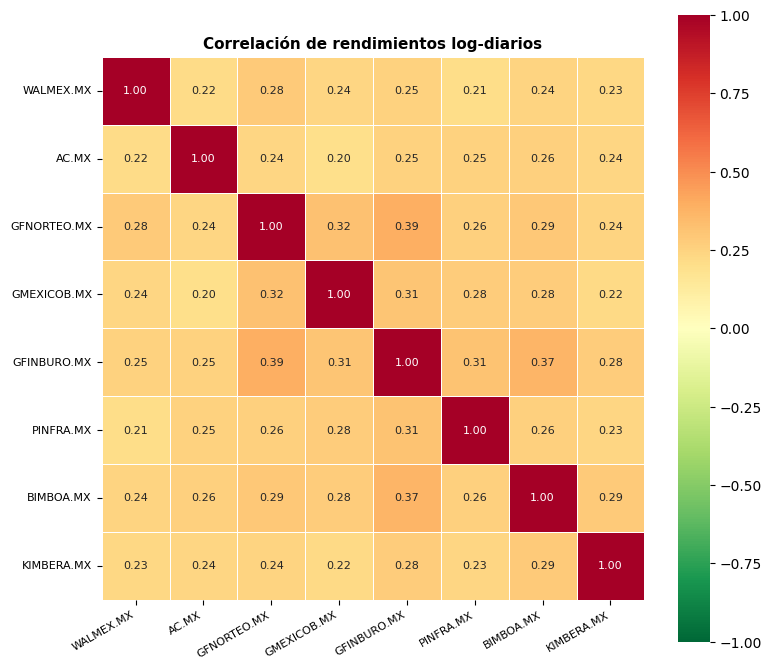


Pares con correlación más BAJA (candidatos más independientes):
   Ticker 1    Ticker 2  Correlación
      AC.MX GMEXICOB.MX        0.203
  WALMEX.MX   PINFRA.MX        0.209
  WALMEX.MX       AC.MX        0.216
GMEXICOB.MX  KIMBERA.MX        0.224
  WALMEX.MX  KIMBERA.MX        0.227

=== Correlación internacionales ===


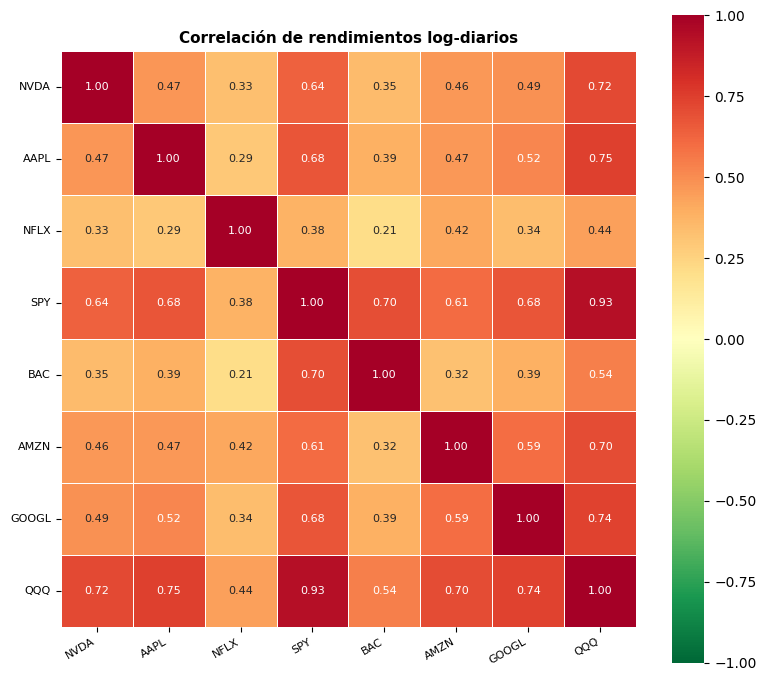


Pares con correlación más BAJA (candidatos más independientes):
Ticker 1 Ticker 2  Correlación
    NFLX      BAC        0.210
    AAPL     NFLX        0.293
     BAC     AMZN        0.321
    NVDA     NFLX        0.332
    NFLX    GOOGL        0.336


In [12]:
def matriz_correlacion(df_rank: pd.DataFrame, n: int = 8,
                        inicio: str = FECHA_INICIO) -> None:
    """Heatmap de correlación de rendimientos entre los top-n."""
    top     = df_rank.head(n)
    tickers = top['ticker'].tolist()
    nombres = top.set_index('ticker')['nombre'].to_dict()

    rets = {}
    for t in tickers:
        try:
            h = yf.Ticker(t).history(start=inicio, auto_adjust=True)['Close'].dropna()
            rets[t] = np.log(h / h.shift(1)).dropna()
        except Exception:
            pass

    df_rets = pd.DataFrame(rets).dropna()
    corr    = df_rets.corr()

    fig, ax = plt.subplots(figsize=(max(6, n), max(5, n-1)))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
                center=0, vmin=-1, vmax=1, ax=ax,
                xticklabels=tickers, yticklabels=tickers,
                linewidths=0.5, square=True, annot_kws={'size': 8})
    ax.set_title('Correlación de rendimientos log-diarios', fontsize=11, fontweight='bold')
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nPares con correlación más BAJA (candidatos más independientes):")
    corr_np = corr.values.copy()
    np.fill_diagonal(corr_np, np.nan)
    corr_flat = pd.DataFrame(corr_np, index=tickers, columns=tickers)
    pares = []
    for i in range(len(tickers)):
        for j in range(i+1, len(tickers)):
            pares.append((tickers[i], tickers[j], round(corr_flat.iloc[i,j], 3)))
    pares_df = pd.DataFrame(pares, columns=['Ticker 1', 'Ticker 2', 'Correlación'])
    print(pares_df.sort_values('Correlación').head(5).to_string(index=False))


print("=== Correlación BMV ===")
matriz_correlacion(df_mx_rank, n=min(8, len(df_mx_rank)))

print("\n=== Correlación internacionales ===")
matriz_correlacion(df_us_rank, n=min(8, len(df_us_rank)))


## 11. Decisión Final

In [13]:
# ── COMPLETA AQUÍ DESPUÉS DE REVISAR LOS RESULTADOS ──────────────────────────
# Pon los tickers elegidos:

EMISORA_MX_1  = df_mx_rank.iloc[0]['ticker']   # default: el mejor score BMV
EMISORA_MX_2  = df_mx_rank.iloc[1]['ticker']   # default: segundo mejor BMV
EMISORA_US_1  = df_us_rank.iloc[0]['ticker']   # default: el mejor score US
EMISORA_US_2  = df_us_rank.iloc[1]['ticker']   # default: segundo mejor US

EMISORAS_SELECCIONADAS = {
    'MX_1': EMISORA_MX_1,
    'MX_2': EMISORA_MX_2,
    'US_1': EMISORA_US_1,
    'US_2': EMISORA_US_2,
}

print("="*50)
print("EMISORAS SELECCIONADAS PARA LA TESIS")
print("="*50)
for clave, ticker in EMISORAS_SELECCIONADAS.items():
    fila_mx = df_mx_rank[df_mx_rank['ticker'] == ticker]
    fila_us = df_us_rank[df_us_rank['ticker'] == ticker]
    fila    = fila_mx if not fila_mx.empty else fila_us
    if not fila.empty:
        f = fila.iloc[0]
        print(f"  {clave}: {ticker:<15} {f['nombre']}")
        print(f"         Años: {f['anos']}  σ: {f['sigma']:.4f}  "
              f"Burs: {f['bursatilidad']:.3f}  Score: {f['score']}")
    else:
        print(f"  {clave}: {ticker}")

# Guardar selección final
print(f"\n✅ Selección lista en memoria: EMISORAS_SELECCIONADAS")
print("\n→ Usa este dict directamente en valuacion_puts_americanas.ipynb")


EMISORAS SELECCIONADAS PARA LA TESIS
  MX_1: WALMEX.MX       Walmart de México
         Años: 16.7  σ: 0.2469  Burs: 0.997  Score: 70.25
  MX_2: AC.MX           Arca Continental
         Años: 16.7  σ: 0.2156  Burs: 0.998  Score: 68.51
  US_1: NVDA            NVIDIA Corp.
         Años: 16.7  σ: 0.4517  Burs: 1.000  Score: 77.5
  US_2: AAPL            Apple Inc.
         Años: 16.7  σ: 0.2812  Burs: 1.000  Score: 75.05

✅ Selección lista en memoria: EMISORAS_SELECCIONADAS

→ Usa este dict directamente en valuacion_puts_americanas.ipynb


## 12. Nota Metodológica para la Tesis

### Por qué estos criterios

**Historial ≥ 8 años:** la simulación GBM necesita estimar σ y μ con suficientes
datos para que los estimadores sean estables. Con menos de 5 años, la volatilidad
histórica tiene un error estándar demasiado grande.

**Bursatilidad ≥ 85%:** un activo que no cotiza frecuentemente introduce precios
artificialmente estables (sin movimiento), lo que sesga σ a la baja.

**% NaN ≤ 5%:** datos faltantes excesivos en la serie de precios invalidan el
supuesto de continuidad del proceso GBM.

**Correlación baja entre emisoras del mismo grupo:** elegir activos muy correlacionados
(ej. dos ETFs que replican el mismo índice) no aporta información adicional al
análisis comparativo.

### Sobre la volatilidad
σ alta no es un defecto — es una característica del activo. Lo que importa
para la tesis es que σ sea **estable en el tiempo** (no que sea pequeña).
Puedes verificar esto con una ventana rolling de 30 días.
